In [1]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'  # MPS fallback for ops not yet implemented on MPS (e.g. linalg_cholesky)

# 00 — Smoke Test

Minimal end-to-end run to verify the cleaned pipeline wires together. Trims epochs, batch size, and top-N for ~3–5 minute completion on Mac MPS or T4. **Run this first** after `pixi install` to confirm everything imports, decodes, scores, trains, and saves before launching real training.

What this notebook tests:
1. `lisardd` package imports without error
2. HierVAE checkpoint loads and decodes
3. MGraphDTA checkpoint loads and scores
4. One short PPO training loop completes and writes to `runs/smoke_run/`
5. Saved artifacts can be loaded back

If any cell fails, the failure points to the broken contract.

In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import torch
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("mps available:", torch.backends.mps.is_available() if hasattr(torch.backends, 'mps') else False)

torch: 2.5.1
cuda available: False
mps available: True


In [3]:
from lisardd.config import ExperimentConfig
from lisardd.runner import run_experiment

cfg = ExperimentConfig(
    run_name="smoke_run",
    algo="ppo",
    reward="prop_high_binders_diff",
    target="jnk3",
    mode="smoke",
    seed=42,
    device="cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"),
)
print(cfg)

ExperimentConfig(run_name='smoke_run', algo='ppo', reward='binding_affinity', target='jnk3', seed=42, mode='smoke', latent_dim=32, hidden_dim=256, batch_size=8, n_epochs=5, n_top=10, t_steps=1, ppo_epochs=6, clip_eps=0.2, gamma=0.95, c1=0.5, c2=0.01, lr_ppo=0.0005, lr_reinforce=0.001, normalize=True, penalty_value=-1.0, greedy=True, w1=0.1, w2=0.1, high_binder_low=7.0, high_binder_high=14.0, high_binder_slope=3.0, use_lr_scheduler=False, lr_scheduler_patience=10, lr_scheduler_factor=0.5, repo_root=PosixPath('/Users/shyamchandra/Library/CloudStorage/GoogleDrive-shyam_chandra@hms.harvard.edu/My Drive/LISARDD_Workshop_Submission/LISARDD'), runs_dir=PosixPath('/Users/shyamchandra/Library/CloudStorage/GoogleDrive-shyam_chandra@hms.harvard.edu/My Drive/LISARDD_Workshop_Submission/LISARDD/runs'), vocab_path=PosixPath('/Users/shyamchandra/Library/CloudStorage/GoogleDrive-shyam_chandra@hms.harvard.edu/My Drive/LISARDD_Workshop_Submission/LISARDD/data/chembl/recovered_vocab_2000.txt'), vae_ckpt_

In [4]:
run_dir = run_experiment(cfg)
print(f"Run saved to: {run_dir}")

/Users/shyamchandra/Library/CloudStorage/GoogleDrive-shyam_chandra@hms.harvard.edu/My Drive/LISARDD_Workshop_Submission/LISARDD/.pixi/envs/default/lib/python3.10/site-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))
/Users/shyamchandra/Library/CloudStorage/GoogleDrive-shyam_chandra@hms.harvard.edu/My Drive/LISARDD_Workshop_Submission/LISARDD/lisardd/generators/hiervae_wrapper.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpic

Episode 0: loss_actor=-0.1690, loss_critic=0.0263, avg_reward=5.4647


100%|██████████| 5/5 [00:22<00:00,  4.47s/it]


Run saved to: /Users/shyamchandra/Library/CloudStorage/GoogleDrive-shyam_chandra@hms.harvard.edu/My Drive/LISARDD_Workshop_Submission/LISARDD/runs/smoke_run


In [5]:
from lisardd.io import load_run

art = load_run(run_dir, load_state=True)
print("history keys:", list(art.history.keys()))
print("top100 rows:", len(art.top100))
print("top reward range:", min(art.top100['reward']), "->", max(art.top100['reward']))
art.top100.head()

history keys: ['average_obj_scores', 'loss_actor_list', 'loss_critic_list']
top100 rows: 10
top reward range: 6.066815376281738 -> 6.3460187911987305


/Users/shyamchandra/Library/CloudStorage/GoogleDrive-shyam_chandra@hms.harvard.edu/My Drive/LISARDD_Workshop_Submission/LISARDD/lisardd/io.py:96: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this exper

,smiles,reward,latent
0,C=O,6.066815,"[-1.936537265777588, -1.1436145305633545, -1.5..."
1,C=O,6.066815,"[-0.7813059687614441, 1.7887777090072632, 1.32..."
2,C=O,6.066815,"[1.7819981575012207, -1.6332907676696777, -1.4..."
3,C=O,6.066815,"[-1.3607257604599, -0.17998695373535156, -0.75..."
4,C=O,6.066815,"[0.7269149422645569, -0.634463369846344, -0.57..."


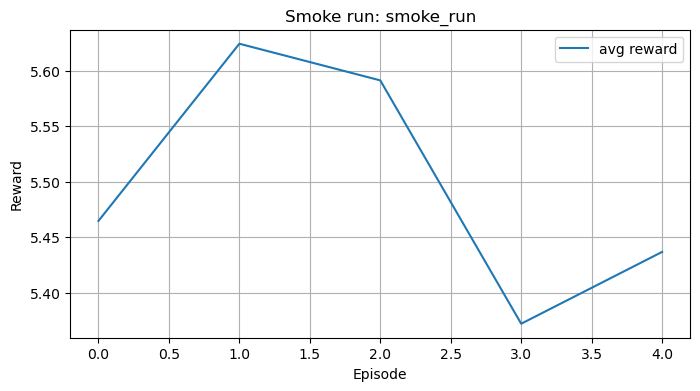

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(art.history['average_obj_scores'], label='avg reward')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title(f"Smoke run: {cfg.run_name}")
plt.legend(); plt.grid(True)
plt.show()

In [5]:
# Debug: test decoder directly with a small random batch to see if MPS decode produces any valid SMILES
import torch
from lisardd.generators.hiervae_wrapper import HierVAEGenerator
from lisardd.decoding.safe_decode import safe_decode_batch

gen = HierVAEGenerator(
    vocab_path=cfg.vocab_path,
    ckpt_path=cfg.vae_ckpt_path,
    device=cfg.device,
    latent_size=cfg.latent_dim,
)
torch.manual_seed(0)
z = torch.randn(5, 3 * cfg.latent_dim, device=cfg.device)
z_chunks = torch.chunk(z, 3, dim=1)
smiles, valid = safe_decode_batch(gen.decoder, z_chunks, greedy=True)
print("smiles:", smiles)
print("valid:", valid)

/Users/shyamchandra/Library/CloudStorage/GoogleDrive-shyam_chandra@hms.harvard.edu/My Drive/LISARDD_Workshop_Submission/LISARDD/.pixi/envs/default/lib/python3.10/site-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))
/Users/shyamchandra/Library/CloudStorage/GoogleDrive-shyam_chandra@hms.harvard.edu/My Drive/LISARDD_Workshop_Submission/LISARDD/lisardd/generators/hiervae_wrapper.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpic

smiles: ['COC(C(=O)C(=O)c1ccccc1)c1ccccc1C', 'Cc1ccc(C(=O)C(Cc2cccc(C)c2)=C(C(=O)c2ccccc2)C(C)C)cc1', 'COCCCCC(c1ccc(Cl)cc1)c1ccc(Cl)cc1', 'CC(C)C(=O)c1cn(C2CCC2)nc1C(=O)c1ccccc1', 'COC(CCc1ccccc1)c1cccc([NH+](C)C)c1']
valid: [True, True, True, True, True]


In [10]:
# Show the actual exception the decoder throws
import traceback
single = tuple(c[0].unsqueeze(0) for c in z_chunks)
try:
    result = gen.decoder.decode(single, greedy=True, max_decode_step=150)
    print("decoded:", result)
except Exception as e:
    traceback.print_exc()

Traceback (most recent call last):
  File "/var/folders/ll/twvrb4wd7c971rnfchtx6wt40000gn/T/ipykernel_37032/3139318480.py", line 5, in <module>
    result = gen.decoder.decode(single, greedy=True, max_decode_step=150)
  File "/Users/shyamchandra/Library/CloudStorage/GoogleDrive-shyam_chandra@hms.harvard.edu/My Drive/LISARDD_Workshop_Submission/LISARDD/hgraph/decoder.py", line 304, in decode
    icls_scores = icls_scores + self.vocab.get_mask(root_cls)
  File "/Users/shyamchandra/Library/CloudStorage/GoogleDrive-shyam_chandra@hms.harvard.edu/My Drive/LISARDD_Workshop_Submission/LISARDD/hgraph/vocab.py", line 55, in get_mask
    return self.mask.index_select(index=cls_idx, dim=0)
RuntimeError: Placeholder storage has not been allocated on MPS device!


In [9]:
# Probe scorer directly on structurally diverse molecules
from lisardd.scoring.mgraphdta_wrapper import MGraphDTAScorer
from lisardd.targets import get_sequence

scorer = MGraphDTAScorer(
    target_protein=get_sequence("jnk3"),
    ckpt_path=cfg.score_ckpt_path,
    device=cfg.device,
)

test_smiles = [
    "C=O",                                                  # formaldehyde — tiny
    "CC(=O)Oc1ccccc1C(=O)O",                               # aspirin
    "O=Cn1c(C(=O)c2ccccc2)cc2c(F)cc(F)cc21",              # from top100
    "c1ccc2[nH]ccc2c1",                                     # indole
    "CC(C)Cc1ccc(C(C)C(=O)O)cc1",                          # ibuprofen
]

scores = scorer.score(test_smiles)
for s, r in zip(test_smiles, scores.tolist()):
    print(f"{r:.4f}  {s}")

/Users/shyamchandra/Library/CloudStorage/GoogleDrive-shyam_chandra@hms.harvard.edu/My Drive/LISARDD_Workshop_Submission/LISARDD/lisardd/scoring/mgraphdta_wrapper.py:122: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issu

6.0668  C=O
5.1805  CC(=O)Oc1ccccc1C(=O)O
5.9926  O=Cn1c(C(=O)c2ccccc2)cc2c(F)cc(F)cc21
5.2589  c1ccc2[nH]ccc2c1
5.1022  CC(C)Cc1ccc(C(C)C(=O)O)cc1


## Done

If the run completed and you see a top100 with non-`None` SMILES plus a reward trajectory, the pipeline is wired correctly. Smoke mode does not produce paper-quality results; it only proves the wiring works.